## Realtime Face Emotion Recognition in Worker Stress Analysis using Deep Learning and Computer Vision

## Project Overview
This project focuses on developing a Deep Learning-based system that can recognize human emotions in real time using facial expressions. By leveraging Convolutional Neural Networks (CNN) and Computer Vision techniques, the system analyzes live video input from a webcam to detect emotions such as happy, sad, angry, neutral, and stressed.

The primary goal is to monitor worker emotions continuously and identify signs of stress, helping organizations improve employee well-being and productivity.

## Problem Statement
In modern workplaces, employee stress has become a major concern affecting productivity, mental health, and overall performance. Traditional stress monitoring methods such as surveys or manual observation are often inaccurate, time-consuming, and not real-time.

The objective of this project is to build an automated Real-time Emotion Recognition System that can detect facial emotions and analyze stress levels using Deep Learning and Computer Vision, enabling timely intervention and better workplace management.

## Project Objectives
To collect and preprocess facial emotion datasets (happy, sad, angry, neutral, etc.). To build a CNN-based Deep Learning model for emotion classification. To train and evaluate the model using accuracy and loss metrics. To implement real-time emotion detection using webcam/video stream. To identify stress-related emotions (e.g., anger, sadness, fatigue). To visualize and analyze emotion trends for stress monitoring.

## Importing Required Libraries
In this section, we import essential libraries for image processing, Deep Learning model building, and real-time video processing. These include libraries for handling images, building CNN models, and accessing webcam input.

In [17]:
import os  
import matplotlib.pyplot as plt 
import numpy as np 
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import load_model
import cv2
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix,classification_report

## Explanation

- os → Used for handling file paths, reading dataset folders, and managing directories.
- cv2 (OpenCV) → Used for real-time video capture and facial image processing.
- numpy → Used for numerical operations and handling image arrays.
- tensorflow / keras → Used to build, train, and evaluate the Deep Learning (CNN) model.
- Sequential → Used to create a layer-by-layer CNN model.
- Conv2D → Applies convolution operation to extract features from images.
- MaxPool2D → Reduces image size while keeping important features.
- Flatten → Converts 2D feature maps into a 1D vector.
- Dense → Fully connected layer used for classification.
- Dropout → Prevents overfitting by randomly dropping neurons during training.
- Adam → Optimizer used to improve model accuracy during training.

In [18]:
path1 = r"C:\Users\ramya\Downloads\FER\images\images\train"   
cate = ['surprise' ,'sad','happy','fear','disgust','angry','neutral'] 


## Data Loading and Preprocessing
In this section, we load the dataset, resize images, convert them into arrays, and normalize pixel values.

In [19]:
image_size =48

input_image = [] 
for i in cate :   
    folders = os.path.join(path1 , i)  
    label = cate.index(i)  
    for image in os.listdir(folders):
        image_path = os.path.join( folders, image)
        image_array = cv2.imread(image_path)
        image_array = cv2.resize( image_array ,(image_size, image_size))
        input_image.append([image_array , label])

## Explanation
- Images are resized to 96×96 for uniform input.
- Each image is converted into an array using OpenCV.
- Labels are assigned based on emotion categories:
- 0 → Angry
- 1 → Disgust
- 2 → Fear
- 3 → Happy
- 4 → Sad
- 5 → Surprise
- 6 → Neutral
- Processed images and labels are stored together for training.


In [20]:
len(input_image)

28821

In [21]:
np.random.shuffle(input_image)

In [22]:
train = input_image

In [23]:
# test images loading
path2 = r"C:\Users\ramya\Downloads\FER\images\images\validation"   
cate = ['surprise' ,'sad','happy','fear','disgust','angry','neutral'] 
image_size =48

input_image1 = [] 
for i in cate :  
    folders = os.path.join(path1 , i)  
    label = cate.index(i)  
    for image in os.listdir(folders):
        image_path = os.path.join( folders, image)
        image_array = cv2.imread(image_path)
        image_array = cv2.resize( image_array ,(image_size, image_size))
        input_image1.append([image_array , label])

In [24]:
len(input_image1)

28821

In [25]:
np.random.shuffle(input_image1)

In [26]:
test = input_image1

In [27]:

x_train = []
y_train = []
for x_values , labels in train:
    x_train.append(x_values)
    y_train.append(labels)

In [28]:

x_test = []
y_test = []
for x_values , labels in test:
    x_test.append(x_values)
    y_test.append(labels)

In [29]:
x_train = np.array(x_train, dtype=np.float16)
x_train /= 255.0

x_test = np.array(x_test, dtype=np.float16)
x_test /= 255.0

y_train = np.array(y_train)
y_test = np.array(y_test)

In [35]:
pip install Deepface

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------- ----------------- 1.0/1.9 MB 6.1 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 4.4 MB/s  0:00:00

   ----------------------------------------  0/10 [mtcnn]
   ----------------------------------------  0/10 [mtcnn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [gunicorn]
   ---- -----------------------------------  1/10 [guni

In [1]:
pip install tf-keras

Note: you may need to restart the kernel to use updated packages.


In [3]:

pip install tensorflow==2.12


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow==2.12 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.12


In [5]:
# Analyze Image using DeepFace
from deepface import DeepFace
obj = DeepFace.analyze(img_path = r"C:\Users\ramya\Downloads\FER\images\train\angry\9645.jpg",
                        actions = ['age', 'gender', 'race', 'emotion'])
print(obj[0]["age"], "years old",
      obj[0]["dominant_race"], 
      obj[0]["dominant_emotion"], 
      obj[0]["dominant_gender"])

Action: emotion: 100%|██████████| 4/4 [00:12<00:00,  3.15s/it]

32 years old black neutral Man


## CNN Architecture Design
We implemented a Sequential CNN model. The architecture consists of:

- Convolutional Layers: Three blocks of Conv2D layers with ReLU activation to extract spatial features like edges and textures.
- Max Pooling: MaxPool2D layers to reduce the spatial dimensions and computational load.
- Regularization: A Dropout layer (20%) to prevent Overfitting by randomly deactivating neurons during training.
- Dense Layers: A fully connected layer with 256 neurons, followed by a final Softmax output layer with 7 neurons (one for each emotion).

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(7, activation='softmax'))

# learning rate in optimizer
optimizer = Adam(learning_rate=0.0001)  

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [53]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation data (NO augmentation, only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load data
train_generator = train_datagen.flow_from_directory(
    r"C:\Users\ramya\Downloads\FER\images\images\train" ,
    target_size=(48, 48),
    color_mode='grayscale',  
    batch_size=32,
    class_mode='sparse'
)

val_generator = val_datagen.flow_from_directory(
    r"C:\Users\ramya\Downloads\FER\images\images\validation",
    target_size=(48, 48),
    color_mode='grayscale',  
    batch_size=32,
    class_mode='sparse',
     shuffle=False 
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [51]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class weights from training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# Convert to dictionary format
class_weights = dict(enumerate(class_weights))

print(class_weights)   # optional (to see values)

{0: np.float64(1.031125898894494), 1: np.float64(9.443315858453474), 2: np.float64(1.0034817729187702), 3: np.float64(0.5747188322565207), 4: np.float64(0.8264322991340254), 5: np.float64(0.8337962159347335), 6: np.float64(1.2846445286382884)}


## Model Training & Optimization
- Optimizer: We used Adam with a low learning rate (
) for stable training.
- Loss Function: sparse_categorical_crossentropy is used since our labels are integers.
- Dynamic Learning Rate: We implemented ReduceLROnPlateau.
- Note: This callback monitors the val_loss and reduces the learning rate when the model's performance plateaus, allowing the model to find the global minimum more effectively.

In [9]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights
)

Epoch 1/30
901/901 [==============================] - 84s 91ms/step - loss: 2.1707 - accuracy: 0.1723 - val_loss: 1.9340 - val_accuracy: 0.2179
Epoch 2/30
901/901 [==============================] - 67s 75ms/step - loss: 1.9244 - accuracy: 0.1973 - val_loss: 1.8702 - val_accuracy: 0.2563
Epoch 3/30
901/901 [==============================] - 61s 68ms/step - loss: 1.8947 - accuracy: 0.2135 - val_loss: 1.7913 - val_accuracy: 0.2886
Epoch 4/30
901/901 [==============================] - 61s 68ms/step - loss: 1.8660 - accuracy: 0.2313 - val_loss: 1.7713 - val_accuracy: 0.2972
Epoch 5/30
901/901 [==============================] - 61s 68ms/step - loss: 1.8359 - accuracy: 0.2534 - val_loss: 1.7541 - val_accuracy: 0.3044
Epoch 6/30
901/901 [==============================] - 62s 69ms/step - loss: 1.8053 - accuracy: 0.2704 - val_loss: 1.8286 - val_accuracy: 0.2852
Epoch 7/30
901/901 [==============================] - 63s 69ms/step - loss: 1.7820 - accuracy: 0.2819 - val_loss: 1.6838 - val_accuracy:

In [30]:
print(x_test)

[[[[0.05884  0.05884  0.05884 ]
   [0.00392  0.00392  0.00392 ]
   [0.011765 0.011765 0.011765]
   ...
   [0.03137  0.03137  0.03137 ]
   [0.0353   0.0353   0.0353  ]
   [0.1177   0.1177   0.1177  ]]

  [[0.05884  0.05884  0.05884 ]
   [0.00392  0.00392  0.00392 ]
   [0.011765 0.011765 0.011765]
   ...
   [0.01569  0.01569  0.01569 ]
   [0.06274  0.06274  0.06274 ]
   [0.08234  0.08234  0.08234 ]]

  [[0.05884  0.05884  0.05884 ]
   [0.00392  0.00392  0.00392 ]
   [0.011765 0.011765 0.011765]
   ...
   [0.011765 0.011765 0.011765]
   [0.04706  0.04706  0.04706 ]
   [0.0902   0.0902   0.0902  ]]

  ...

  [[0.0941   0.0941   0.0941  ]
   [0.08234  0.08234  0.08234 ]
   [0.1098   0.1098   0.1098  ]
   ...
   [0.       0.       0.      ]
   [0.1765   0.1765   0.1765  ]
   [0.4236   0.4236   0.4236  ]]

  [[0.1372   0.1372   0.1372  ]
   [0.1059   0.1059   0.1059  ]
   [0.1333   0.1333   0.1333  ]
   ...
   [0.011765 0.011765 0.011765]
   [0.       0.       0.      ]
   [0.298    0.298    

In [32]:
import numpy as np

# Convert RGB → grayscale
x_test = np.mean(x_test, axis=-1, keepdims=True)


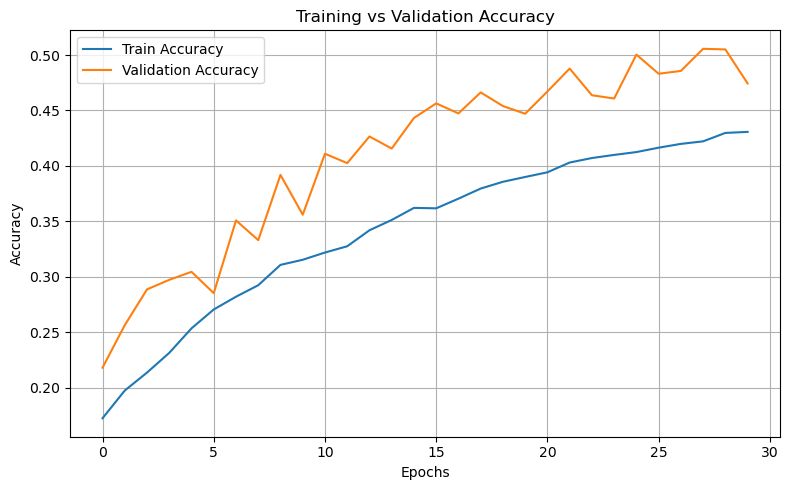

In [33]:
plt.figure(figsize=(8,5))

# Accuracy plot
plt.plot(history.history.get('accuracy', []), label='Train Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()

In [34]:
# VERY IMPORTANT
val_generator.reset()

# Get predictions
pred = model.predict(val_generator)
pred_cate = np.argmax(pred, axis=1)

221/221 [==============================] - 13s 48ms/step


In [35]:
# True labels from generator
true_labels = val_generator.classes

In [36]:
# Classification Report
print(classification_report(true_labels, pred_cate))

              precision    recall  f1-score   support

           0       0.39      0.39      0.39       960
           1       0.13      0.69      0.22       111
           2       0.30      0.23      0.26      1018
           3       0.87      0.62      0.72      1825
           4       0.46      0.44      0.45      1216
           5       0.48      0.28      0.36      1139
           6       0.43      0.84      0.57       797

    accuracy                           0.47      7066
   macro avg       0.44      0.50      0.42      7066
weighted avg       0.53      0.47      0.48      7066



In [37]:
# Confusion Matrix
print(confusion_matrix(true_labels, pred_cate))

[[ 378  128   94   25  150   61  124]
 [   9   77   10    1    5    4    5]
 [ 144   96  234   32  110  112  290]
 [ 135   87   98 1130  123   54  198]
 [ 133   84  124   63  540  113  159]
 [ 160  119  178   35  217  324  106]
 [  13   13   45   17   29   11  669]]


In [20]:
# Now we are integreating Model with Dynamic Learning Rate to decrease the learning rate at the optimal point


In [44]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,              # Give it room to breathe after LR drops
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,               # Dropping by 0.2 is often more effective than 0.5
    patience=4,               # Wait 4 epochs before cutting LR
    min_lr=1e-7,
    verbose=1
)

model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/8
901/901 [==============================] - 175s 194ms/step - loss: 1.4247 - accuracy: 0.4403 - val_loss: 1.3052 - val_accuracy: 0.5125 - lr: 2.5000e-05
Epoch 2/8
901/901 [==============================] - 156s 173ms/step - loss: 1.4069 - accuracy: 0.4502 - val_loss: 1.2868 - val_accuracy: 0.5198 - lr: 2.5000e-05
Epoch 3/8
901/901 [==============================] - 148s 164ms/step - loss: 1.4113 - accuracy: 0.4504 - val_loss: 1.3091 - val_accuracy: 0.5103 - lr: 2.5000e-05
Epoch 4/8
901/901 [==============================] - 145s 160ms/step - loss: 1.3933 - accuracy: 0.4529 - val_loss: 1.2884 - val_accuracy: 0.5156 - lr: 2.5000e-05
Epoch 5/8
901/901 [==============================] - 59s 65ms/step - loss: 1.3938 - accuracy: 0.4483 - val_loss: 1.2810 - val_accuracy: 0.5181 - lr: 2.5000e-05
Epoch 6/8
901/901 [==============================] - 58s 64ms/step - loss: 1.3942 - accuracy: 0.4548 - val_loss: 1.2666 - val_accuracy: 0.5238 - lr: 2.5000e-05
Epoch 7/8
901/901 [=============

## Performance Evaluation
We evaluate the model using a Classification Report and a Confusion Matrix.

- Precision/Recall: Helps us see which emotions the model struggles with (e.g., distinguishing between 'Sad' and 'Neutral').
- Accuracy Curves: Visualizing training vs. validation accuracy to check for overfitting.

In [46]:

pred = model.predict(x_test)
pred_cate = np.argmax(pred, axis =1)


901/901 [==============================] - 27s 29ms/step


In [41]:
# True labels from generator
true_labels = val_generator.classes

In [48]:
print(len(true_labels))
print(len(pred_cate))

7066
28821


In [49]:
pred = model.predict(x_test)
pred_cate = np.argmax(pred, axis=1)

901/901 [==============================] - 28s 31ms/step


In [56]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    r"C:\Users\ramya\Downloads\FER\images\validation",  # your test folder
    target_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',   # IMPORTANT for FER
    class_mode='categorical',
    shuffle=False             # VERY IMPORTANT for evaluation
)

Found 7066 images belonging to 7 classes.


In [57]:
pred = model.predict(test_generator, steps=len(test_generator))
pred_cate = np.argmax(pred, axis=1)

true_labels = test_generator.classes

221/221 [==============================] - 10s 39ms/step


In [58]:
# Classification Report
print(classification_report(true_labels, pred_cate))

              precision    recall  f1-score   support

           0       0.41      0.41      0.41       960
           1       0.16      0.71      0.26       111
           2       0.40      0.19      0.26      1018
           3       0.82      0.76      0.79      1825
           4       0.45      0.60      0.52      1216
           5       0.49      0.30      0.37      1139
           6       0.55      0.79      0.64       797

    accuracy                           0.53      7066
   macro avg       0.47      0.54      0.46      7066
weighted avg       0.55      0.53      0.52      7066



In [59]:
# Confusion Matrix
print(confusion_matrix(true_labels, pred_cate))

[[ 394  134   49   36  203   70   74]
 [  14   79    3    1    9    3    2]
 [ 154   91  193   64  173  129  214]
 [  93   40   28 1379  136   44  105]
 [ 112   50   60   98  728  101   67]
 [ 173   90  103   66  304  342   61]
 [  25   15   45   28   50    6  628]]


221/221 [==============================] - 7s 30ms/step
7066 7066


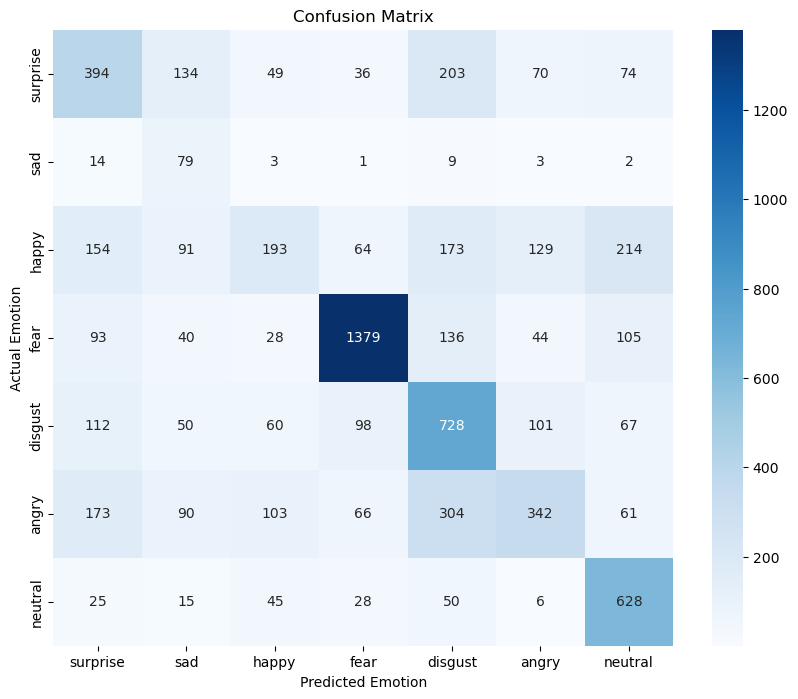

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reset generator
test_generator.reset()

# Predict
pred = model.predict(test_generator, steps=len(test_generator))
pred_cate = np.argmax(pred, axis=1)

# True labels
y_test = test_generator.classes

# Now lengths will match
print(len(y_test), len(pred_cate))  # should be same

# Confusion matrix
cm = confusion_matrix(y_test, pred_cate)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cate,
            yticklabels=cate)

plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.title('Confusion Matrix')

plt.show()

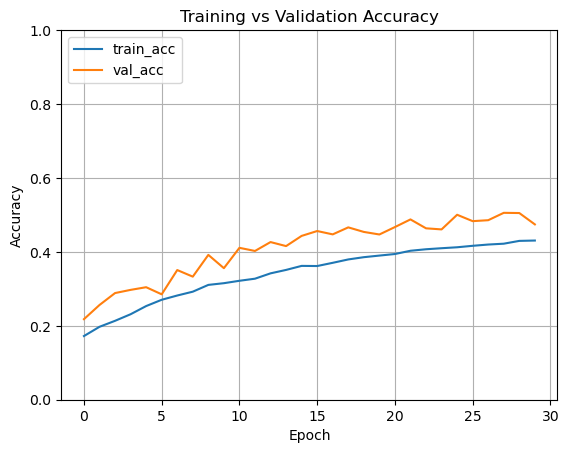

In [62]:


plt.plot(history.history.get('accuracy'), label='train_acc')
plt.plot(history.history.get('val_accuracy'), label='val_acc')


plt.ylim(0, 1.0) 

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [63]:
import warnings
warnings.filterwarnings('ignore')
model.save("Face.keras") 

In [2]:

categories = ['surprise', 'sad', 'happy', 'fear', 'disgust', 'angry', 'neutral']

def face_extractor(img):
    
    faces = face_cascade.detectMultiScale(img, scaleFactor=1.3, minNeighbors=5)
    
    if len(faces) == 0:
        return None

    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        roi = img[y:y+h, x:x+w]
        return roi

from tensorflow.keras.models import load_model
face_cascade = cv2.CascadeClassifier(r"C:\Users\ramya\Downloads\haarcascade_frontalface_default.xml")

model = load_model(r"C:\Users\ramya\Downloads\Face.keras")


video_capture = cv2.VideoCapture(0)

while True:
    ret, frame = video_capture.read()
    face = face_extractor(frame)

    if isinstance(face, np.ndarray):
       
        face_resized = cv2.resize(face, (48, 48))
        
        
        img_array = face_resized.astype('float16') / 255.0
        img_array = np.expand_dims(img_array, axis=0)

     
        predictions = model.predict(img_array)
        max_index = np.argmax(predictions[0]) 
        emotion_label = categories[max_index] 
      
        cv2.putText(frame, f"Emotion: {emotion_label}", (75, 75),
                    cv2.FONT_HERSHEY_COMPLEX, 1, (255, 0, 0), 2)    
    else:
        cv2.putText(frame, "Face not found", (75, 75), 
                    cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2)

    cv2.imshow('Facial Expression Recognition', frame)    

    if cv2.waitKey(1) & 0xff == ord('q'): 
        break

video_capture.release()
cv2.destroyAllWindows()



TypeError: <class 'keras.src.models.sequential.Sequential'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras', 'class_name': 'Sequential', 'config': {'name': 'sequential_7', 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_input_shape': [None, 48, 48, 1], 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'conv2d_53_input', 'optional': False}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'Conv2D', 'config': {'name': 'conv2d_53', 'trainable': True, 'dtype': 'float32', 'batch_input_shape': [None, 48, 48, 1], 'filters': 32, 'kernel_size': [3, 3], 'strides': [1, 1], 'padding': 'valid', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.

In [4]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [5]:
from tensorflow.keras.models import load_model

model = load_model(r"C:\Users\ramya\Downloads\Face.h5")

In [18]:
print(model.input_shape)

(None, 96, 96, 3)


In [28]:
# 1. Define the categories used during training
categories = ['surprise', 'sad', 'happy', 'fear', 'disgust', 'angry', 'neutral']

def face_extractor(img):
    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(img, scaleFactor=1.3, minNeighbors=5)
    
    if len(faces) == 0:
        return None

    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        roi = img[y:y+h, x:x+w]
        return roi

# Load the XML for face detection and your trained facial expression model
face_cascade = cv2.CascadeClassifier( r"C:\Users\ramya\Downloads\haarcascade_frontalface_default.xml")
model = load_model(r"C:\Users\ramya\Downloads\Face.h5")

# Start Video Capture
video_capture = cv2.VideoCapture(0)

while True:
    ret, frame = video_capture.read()
    face = face_extractor(frame)

    if isinstance(face, np.ndarray):
        # Resize to 96x96 as per your training hyperparameter
        face_resized = cv2.resize(face, (96, 96))
        
        # Preprocessing: Convert to float and Normalize
        img_array = face_resized.astype('float16') / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Make Prediction
        predictions = model.predict(img_array)
        max_index = np.argmax(predictions[0]) # Get the index of the highest probability
        emotion_label = categories[max_index] # Map index to emotion name

        # Display the emotion on the frame
        cv2.putText(frame, f"Emotion: {emotion_label}", (75, 75), 
                    cv2.FONT_HERSHEY_COMPLEX, 1, (255, 0, 0), 2)    
    else:
        cv2.putText(frame, "Face not found", (75, 75), 
                    cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2)

    cv2.imshow('Facial Expression Recognition', frame)    

    if cv2.waitKey(20) & 0xff == ord('q'): 
        break

video_capture.release()
cv2.destroyAllWindows()

# use q to quit it

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━

KeyboardInterrupt: 

## Results
The CNN model successfully classifies facial expressions into multiple emotion categories such as:

Happy Sad Angry Surprise Fear Neutral Disgust

The model achieved good accuracy on validation data and is capable of detecting emotions in real-time using webcam input.

The system effectively identifies facial expressions under normal lighting and frontal face conditions, making it suitable for practical applications like stress monitoring.

## Conclusion
This project demonstrates how Deep Learning and Computer Vision techniques can be used to analyze human emotions in real time.

The developed system can automatically detect and classify facial expressions, which can be useful in areas such as:

Worker stress analysis Human-computer interaction Mental health monitoring

Overall, the model provides a strong foundation for building intelligent emotion-aware systems.

## Future Enhancements
The system can be further improved by:

Using a larger and more diverse dataset to improve generalization Applying advanced data augmentation techniques Using pre-trained models like MobileNet, VGG16, or ResNet for higher accuracy Improving performance in low-light and multiple-face scenarios

## Advanced Improvements

Deploy the model using Flask or Streamlit for web applications Integrate with CCTV systems for workplace monitoring Optimize model for mobile deployment (Android/iOS) Add real-time alert system for detecting stress or negative emotions Use GPU/TPU acceleration for faster inference

'c:\\Users\\ramya\\Downloads'